# Heston Monte Carlo Variance Derivatives Demo

In [27]:
from pathlib import Path
import sys
from IPython.display import Image, display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from heston_mc.params import default_heston_params, MonteCarloConfig
from heston_mc.interfaces import SimulationResult
from heston_mc.simulation import HestonModelSimulator
from heston_mc.realized_variance import realized_variance_from_prices
from heston_mc.variance_swap import variance_swap_payoff, price_variance_swap
from heston_mc.variance_option import variance_option_payoff, price_variance_option
from heston_mc.control_variate import (
    expected_average_variance,
    compare_variance_swap_methods,
    price_variance_swap_control_variate,
    price_variance_option_control_variate,
    standard_error_improvement_ratio,
)

In [9]:
cwd = Path.cwd().resolve()
candidate_roots = [cwd, cwd.parent, cwd.parent.parent]
PROJECT_ROOT = None
for candidate in candidate_roots:
    if (candidate / "src" / "heston_mc").exists():
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    raise RuntimeError("Could not find project root. Put this notebook in the repo root or notebooks/ folder.")
sys.path.insert(0, str(PROJECT_ROOT / "src"))
print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/chiggachuuuuu/Documents/研究生/Columbia MAFN/2026 Spring/MATH 5030/Project/MATH5030GR-project-main


In [11]:
params = default_heston_params()
config = MonteCarloConfig(
    maturity=1.0,
    n_steps=252,
    n_paths=5_000,
    seed=42,
    periods_per_year=252,
)
strike = params.theta
rate = params.r
maturity = config.maturity

display(pd.DataFrame({
    "Parameter": ["s0", "v0", "r", "q", "kappa", "theta", "sigma", "rho", "maturity", "n_steps", "n_paths"],
    "Value": [params.s0, params.v0, params.r, params.q, params.kappa, params.theta, params.sigma, params.rho, config.maturity, config.n_steps, config.n_paths],
}))

,Parameter,Value
0,s0,100.00
1,v0,0.04
2,r,0.03
3,q,0.00
4,kappa,2.00
5,theta,0.04
6,sigma,0.50
7,rho,-0.70
8,maturity,1.00
9,n_steps,252.00


## 1. Heston simulation section

This section simulates joint paths of the stock price $S_t$ and instantaneous variance $v_t$.

The simulator uses the `HestonModelSimulator` class and returns two arrays:

- `stock_paths`, with shape `(n_paths, n_steps + 1)`;
- `variance_paths`, with shape `(n_paths, n_steps + 1)`.

The variance update uses full truncation through $v^+ = \max(v,0)$ so that the square-root term remains numerically stable.

In [12]:
simulator = HestonModelSimulator(params, config)
stock_paths, variance_paths = simulator.simulate()
dt = config.maturity / config.n_steps
sim_result = SimulationResult(
    stock_paths=stock_paths,
    variance_paths=variance_paths,
    dt=dt,
)

In [13]:
print("stock_paths shape:", stock_paths.shape)
print("variance_paths shape:", variance_paths.shape)
print("dt:", dt)

stock_paths shape: (5000, 253)
variance_paths shape: (5000, 253)
dt: 0.003968253968253968


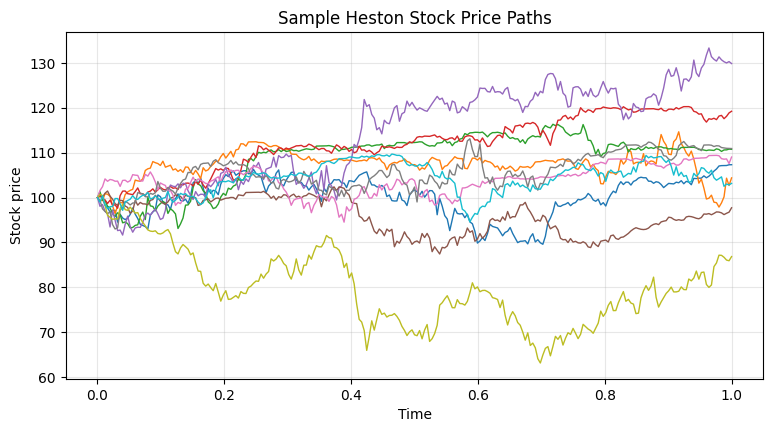

In [14]:
time_grid = np.linspace(0, config.maturity, config.n_steps + 1)
plt.figure(figsize=(9, 4.5))
for i in range(10):
    plt.plot(time_grid, stock_paths[i], linewidth=1)
plt.title("Sample Heston Stock Price Paths")
plt.xlabel("Time")
plt.ylabel("Stock price")
plt.grid(alpha=0.3)
plt.show()

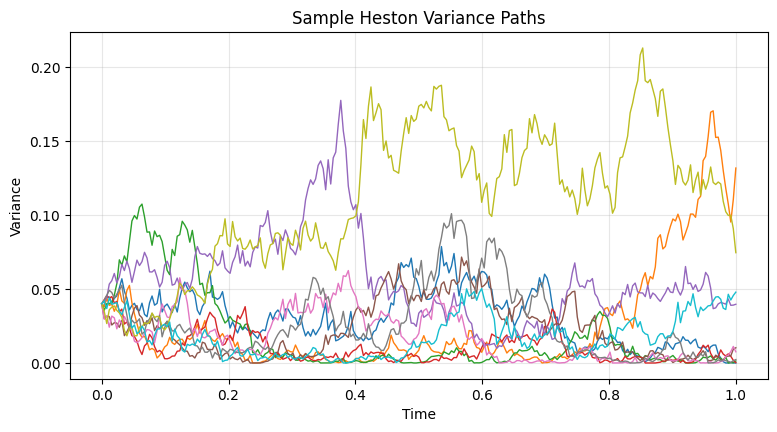

In [15]:
plt.figure(figsize=(9, 4.5))
for i in range(10):
    plt.plot(time_grid, np.maximum(variance_paths[i], 0), linewidth=1)
plt.title("Sample Heston Variance Paths")
plt.xlabel("Time")
plt.ylabel("Variance")
plt.grid(alpha=0.3)
plt.show()

## 2. Realized variance and variance swap section

The package computes realized variance from **simple returns**:

$$
R_i = \frac{S_{t_i} - S_{t_{i-1}}}{S_{t_{i-1}}}.
$$

For each path, the realized variance estimator is:

$$
RV = \frac{1}{T}\sum_{i=1}^{N} R_i^2.
$$

A variance swap has payoff:

$$
RV - K_{var}.
$$

In [16]:
realized_variance = realized_variance_from_prices(stock_paths, dt)
rv_summary = pd.Series(realized_variance).describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
display(rv_summary.to_frame("Realized variance"))

,Realized variance
count,5000.000000
mean,0.040242
std,0.031309
min,0.003122
5%,0.009537
25%,0.018534
50%,0.030565
75%,0.052679
95%,0.102551
max,0.256943


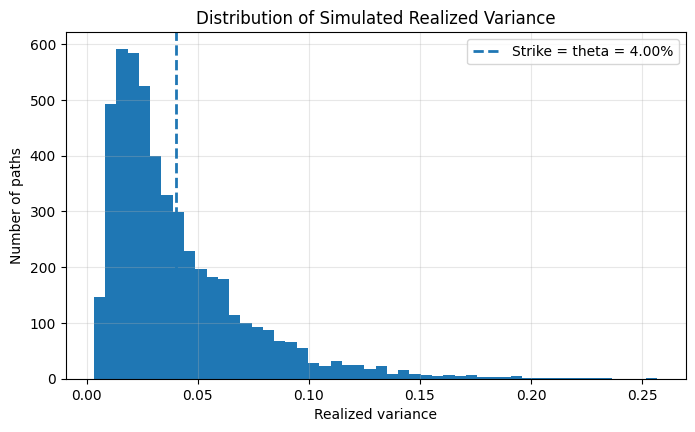

In [17]:
plt.figure(figsize=(8, 4.5))
plt.hist(realized_variance, bins=50)
plt.axvline(strike, linestyle="--", linewidth=2, label=f"Strike = theta = {strike:.2%}")
plt.title("Distribution of Simulated Realized Variance")
plt.xlabel("Realized variance")
plt.ylabel("Number of paths")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [18]:
swap_payoffs = variance_swap_payoff(realized_variance, strike)
swap_plain = price_variance_swap(sim_result, strike=strike, rate=rate, maturity=maturity)

swap_table = pd.DataFrame([
    {
        "method": swap_plain.method_name,
        "price": swap_plain.price,
        "std_error": swap_plain.std_error,
        "n_paths": swap_plain.n_paths,
        "n_steps": swap_plain.n_steps,
        "runtime_seconds": swap_plain.runtime_seconds,
    }
])
display(swap_table)

,method,price,std_error,n_paths,n_steps,runtime_seconds
0,plain_mc_variance_swap,0.000235,0.00043,5000,252,0.011063


## 3. Variance option section

A variance call option has nonlinear payoff:

$$
\max(RV - K_{var}, 0).
$$

Compared with the variance swap, this payoff keeps only the upside of realized variance above the strike. This makes the option price more sensitive to the right tail of the realized-variance distribution.

In [19]:
option_payoffs = variance_option_payoff(realized_variance, strike)
option_plain = price_variance_option(sim_result, strike=strike, rate=rate, maturity=maturity)
option_table = pd.DataFrame([
    {
        "method": option_plain.method_name,
        "price": option_plain.price,
        "std_error": option_plain.std_error,
        "n_paths": option_plain.n_paths,
        "n_steps": option_plain.n_steps,
        "runtime_seconds": option_plain.runtime_seconds,
    }
])
display(option_table)

,method,price,std_error,n_paths,n_steps,runtime_seconds
0,plain_mc_variance_option,0.011292,0.000333,5000,252,0.010328


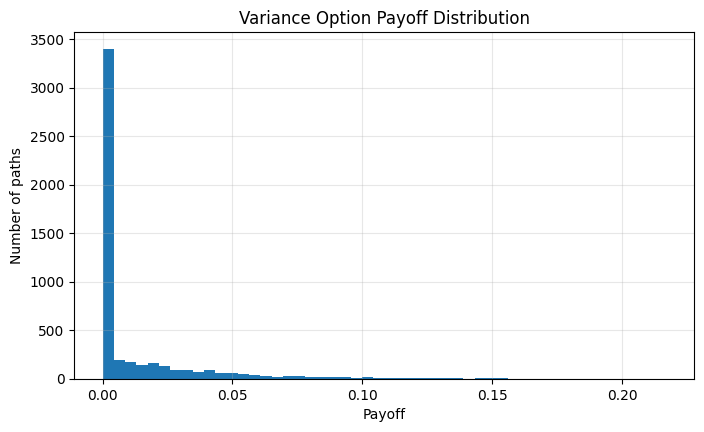

In [20]:
plt.figure(figsize=(8, 4.5))
plt.hist(option_payoffs, bins=50)
plt.title("Variance Option Payoff Distribution")
plt.xlabel("Payoff")
plt.ylabel("Number of paths")
plt.grid(alpha=0.3)
plt.show()

## 4. Control variate section

The control variate estimator adjusts a noisy Monte Carlo target sample $X$ using a correlated control sample $Y$ with known expectation $\mathbb{E}[Y]$:

$$
X_{CV} = X - \beta(Y - \mathbb{E}[Y]).
$$

The package uses discounted realized variance as the control because its expected average variance under the Heston variance process has a closed-form expression:

$$
\mathbb{E}\left[\frac{1}{T}\int_0^T v_tdt\right]
= \theta + (v_0 - \theta)\frac{1-e^{-\kappa T}}{\kappa T}.
$$

In the default parameters, $v_0 = \theta = 0.04$, so this expected average variance is exactly $0.04$.

In [21]:
expected_rv_control = expected_average_variance(params, maturity)
print(f"Control mean E[average variance] = {expected_rv_control:.6f}")
print(f"Variance strike K_var = {strike:.6f}")

Control mean E[average variance] = 0.040000
Variance strike K_var = 0.040000


In [22]:
swap_cv = price_variance_swap_control_variate(
    sim_result=sim_result,
    strike=strike,
    rate=rate,
    maturity=maturity,
    params=params,
)

option_cv = price_variance_option_control_variate(
    sim_result=sim_result,
    strike=strike,
    rate=rate,
    maturity=maturity,
    params=params,
)

comparison_table = pd.DataFrame([
    {
        "product": "Variance swap",
        "plain_price": swap_plain.price,
        "plain_se": swap_plain.std_error,
        "cv_price": swap_cv.price,
        "cv_se": swap_cv.std_error,
        "se_improvement_ratio": standard_error_improvement_ratio(swap_plain.std_error, swap_cv.std_error),
    },
    {
        "product": "Variance option",
        "plain_price": option_plain.price,
        "plain_se": option_plain.std_error,
        "cv_price": option_cv.price,
        "cv_se": option_cv.std_error,
        "se_improvement_ratio": standard_error_improvement_ratio(option_plain.std_error, option_cv.std_error),
    },
])

display(comparison_table)

,product,plain_price,plain_se,cv_price,cv_se,se_improvement_ratio
0,Variance swap,0.000235,0.000430,-1.471117e-18,7.792962e-20,5.513898e+15
1,Variance option,0.011292,0.000333,1.111990e-02,1.047376e-04,3.177535e+00


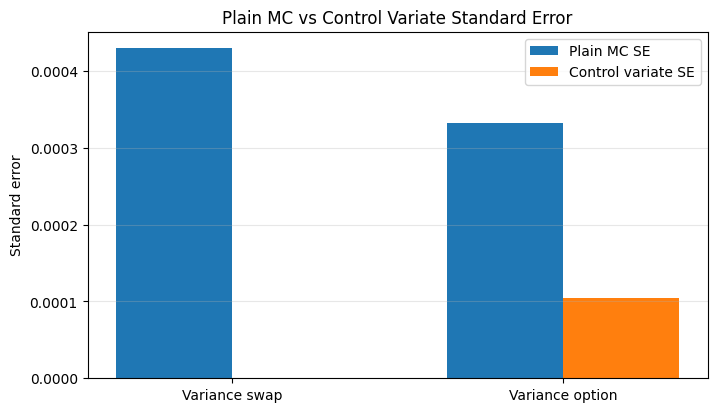

In [23]:
plt.figure(figsize=(8, 4.5))
labels = comparison_table["product"]
x = np.arange(len(labels))
width = 0.35
plt.bar(x - width/2, comparison_table["plain_se"], width, label="Plain MC SE")
plt.bar(x + width/2, comparison_table["cv_se"], width, label="Control variate SE")
plt.xticks(x, labels)
plt.ylabel("Standard error")
plt.title("Plain MC vs Control Variate Standard Error")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

**Interpretation note.** For the variance swap, the control variate can become almost exact under the default setup because the target payoff is linear in realized variance and the chosen control is also realized variance. For the variance option, the payoff is nonlinear, so the improvement is still meaningful but not exact.

## 5. Experiments/results section

The results summarize:

- path-count sensitivity;
- time-step sensitivity;
- parameter robustness;
- efficiency improvement from control variates.


In [24]:
results_dir = PROJECT_ROOT / "results"
path_sensitivity = pd.read_csv(results_dir / "path_sensitivity.csv")
timestep_sensitivity = pd.read_csv(results_dir / "timestep_sensitivity.csv")
parameter_robustness = pd.read_csv(results_dir / "parameter_robustness.csv")

In [25]:
display(path_sensitivity)
display(timestep_sensitivity)
display(parameter_robustness)

,n_paths,plain_se,cv_se,se_reduction,plain_runtime,cv_runtime
0,5000,0.000333,0.000105,3.177535,0.014640,0.005917
1,10000,0.000239,0.000075,3.187669,0.005031,0.009678
2,20000,0.000171,0.000053,3.208387,0.039313,0.019844
3,50000,0.000105,0.000034,3.143231,0.091446,0.048679
4,100000,0.000075,0.000024,3.165687,0.197552,0.301204


,n_steps,plain_price,cv_price,plain_se,cv_se,cv_runtime
0,50,0.011428,0.011276,0.000245,0.000077,0.004472
1,100,0.011182,0.011134,0.000238,0.000076,0.004948
2,252,0.011505,0.011112,0.000239,0.000075,0.009854
3,500,0.011276,0.011072,0.000241,0.000076,0.018503


,Scenario,Plain_SE,CV_SE,SE_Reduction_Ratio
0,Baseline,0.000171,0.000053,3.208387
1,High Vol of Vol,0.000345,0.000073,4.698378
2,Strong Neg Correlation,0.000171,0.000053,3.212217
3,Longer Maturity,0.000125,0.000043,2.931985


se_convergence_paths.png


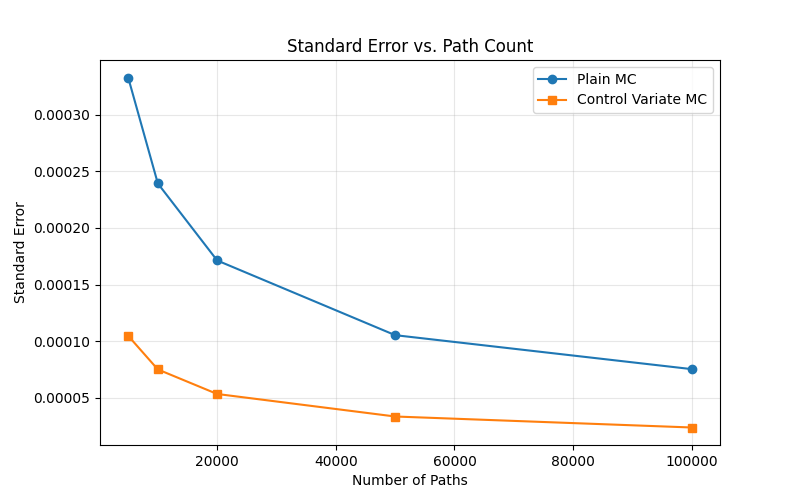

price_convergence_steps.png


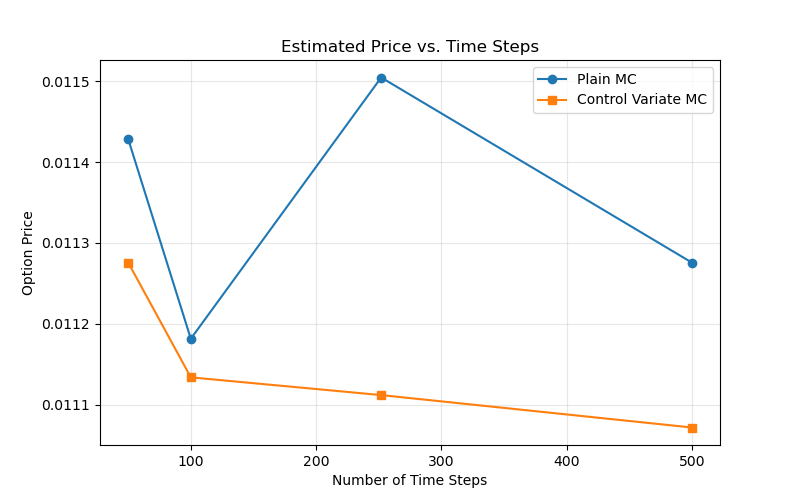

robustness_efficiency_bar.png


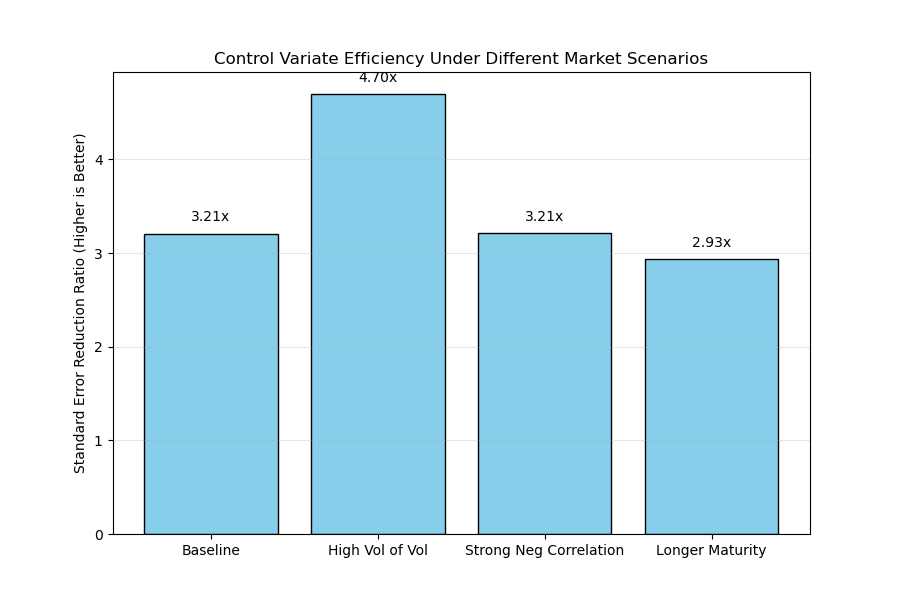

In [28]:
for image_name in [
    "se_convergence_paths.png",
    "price_convergence_steps.png",
    "robustness_efficiency_bar.png",
]:
    image_path = results_dir / image_name
    if image_path.exists():
        print(image_name)
        display(Image(filename=str(image_path)))

## Final takeaway

The package gives a complete Monte Carlo workflow for Heston variance derivatives:

1. simulate Heston paths;
2. compute realized variance from simple returns;
3. price variance swaps and variance options;
4. reduce Monte Carlo noise with control variates;
5. summarize convergence and robustness through experiments.